# AIML Computer Vision Case Study
## Training and Evaluating CNN Models on CIFAR-100

In [3]:
# Install utilities for plotting model architectures in Colab
!pip -q install pydot graphviz


## 2. Imports

In [4]:
# Import the required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from IPython.display import Image, display

print(tf.__version__)


2.20.0


## 3. Load and Preprocess CIFAR-100
We normalize image pixels to the range `[0, 1]` and one-hot encode the labels.

In [5]:
# Load CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
num_classes = 100
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


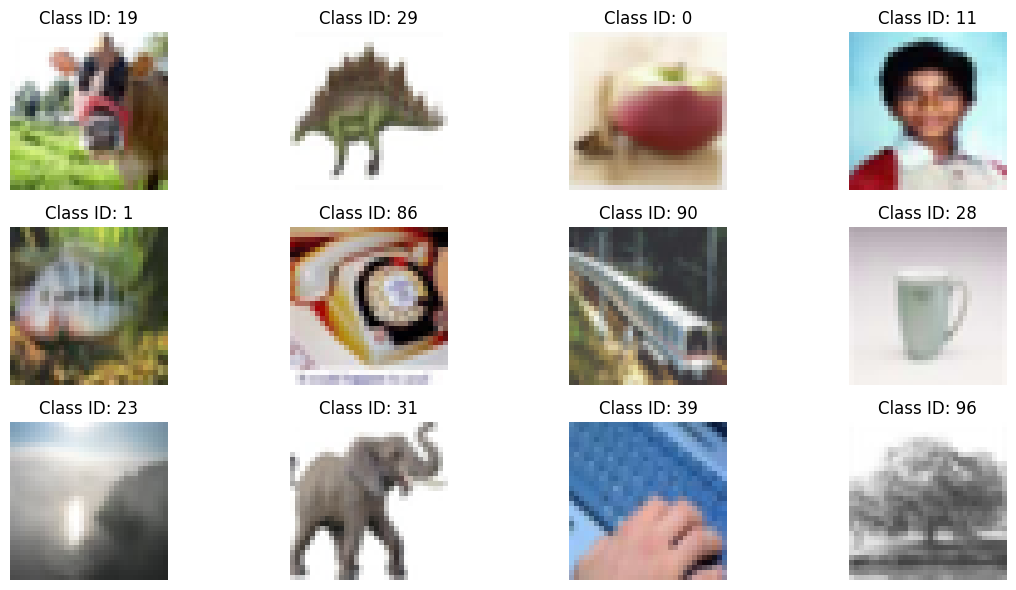

In [6]:
# Display sample images from CIFAR-100
plt.figure(figsize=(12, 6))
for idx in range(12):
    plt.subplot(3, 4, idx + 1)
    plt.imshow(x_train[idx])
    plt.title('Class ID: ' + str(int(y_train[idx][0])))
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Custom CNN Design

In [7]:
# Build a configurable custom CNN model
def build_custom_cnn(dropout_rate=0.4, use_batchnorm=True, kernel_init='he_normal', activation_name='relu'):
    model = models.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))

    model.add(layers.Conv2D(32, (3, 3), padding='same', activation=activation_name,
                            kernel_initializer=kernel_init,
                            kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation=activation_name,
                            kernel_initializer=kernel_init,
                            kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), padding='same', activation=activation_name,
                            kernel_initializer=kernel_init,
                            kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation=activation_name,
                            kernel_initializer=kernel_init,
                            kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.30))

    model.add(layers.Conv2D(128, (3, 3), padding='same', activation=activation_name,
                            kernel_initializer=kernel_init,
                            kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation=activation_name,
                            kernel_initializer=kernel_init,
                            kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation=activation_name, kernel_initializer=kernel_init))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(100, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 840,068 (3.20 MB)

 Trainable params: 838,660 (3.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

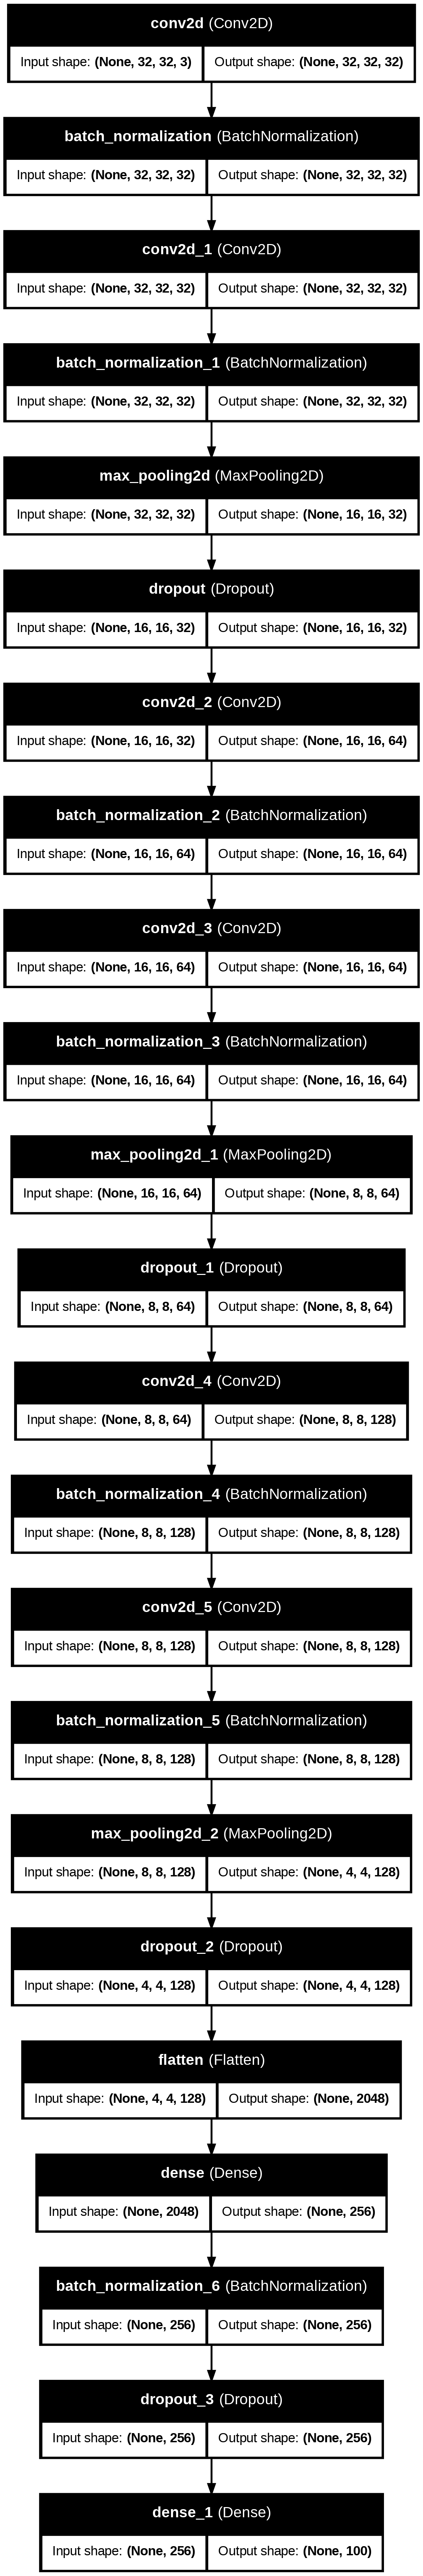

In [8]:
# Plot the custom CNN architecture
plot_model(custom_cnn, to_file='custom_cnn_architecture.png', show_shapes=True, show_layer_names=True)
display(Image(filename='custom_cnn_architecture.png'))


## 5. Small Experimentation Section for the Custom CNN

In [9]:
# Create a small subset for quick experiments
subset_train_size = 10000
subset_val_size = 2000

x_exp_train = x_train[:subset_train_size]
y_exp_train = y_train_cat[:subset_train_size]
x_exp_val = x_train[subset_train_size:subset_train_size + subset_val_size]
y_exp_val = y_train_cat[subset_train_size:subset_train_size + subset_val_size]

print(x_exp_train.shape)
print(x_exp_val.shape)

(10000, 32, 32, 3)
(2000, 32, 32, 3)


In [10]:
# Run a few lightweight experiments for the custom CNN
experiment_configs = [
    {'name': 'Baseline', 'dropout_rate': 0.4, 'use_batchnorm': True, 'kernel_init': 'he_normal', 'activation_name': 'relu'},
    {'name': 'No_BatchNorm', 'dropout_rate': 0.4, 'use_batchnorm': False, 'kernel_init': 'he_normal', 'activation_name': 'relu'},
    {'name': 'Higher_Dropout', 'dropout_rate': 0.5, 'use_batchnorm': True, 'kernel_init': 'he_normal', 'activation_name': 'relu'},
    {'name': 'Glorot_Init', 'dropout_rate': 0.4, 'use_batchnorm': True, 'kernel_init': 'glorot_uniform', 'activation_name': 'relu'}
]

experiment_results = []

for config_item in tqdm(experiment_configs):
    exp_model = build_custom_cnn(
        dropout_rate=config_item['dropout_rate'],
        use_batchnorm=config_item['use_batchnorm'],
        kernel_init=config_item['kernel_init'],
        activation_name=config_item['activation_name']
    )

    exp_history = exp_model.fit(
        x_exp_train, y_exp_train,
        validation_data=(x_exp_val, y_exp_val),
        epochs=3,
        batch_size=64,
        verbose=0
    )

    best_val_acc = max(exp_history.history['val_accuracy'])
    experiment_results.append({
        'Experiment': config_item['name'],
        'Best Validation Accuracy': best_val_acc
    })

experiment_df = pd.DataFrame(experiment_results).sort_values('Best Validation Accuracy', ascending=False)
experiment_df


  0%|          | 0/4 [00:00<?, ?it/s]

,Experiment,Best Validation Accuracy
0,Baseline,0.1375
2,Higher_Dropout,0.1160
3,Glorot_Init,0.0880
1,No_BatchNorm,0.0700


## 6. Final Custom CNN for Full Training

In [11]:
# Rebuild the selected custom CNN for full training
custom_cnn = build_custom_cnn(dropout_rate=0.4, use_batchnorm=True, kernel_init='he_normal', activation_name='relu')
custom_cnn.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 840,068 (3.20 MB)

 Trainable params: 838,660 (3.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 7. VGG-16 Model Using Keras

In [12]:
# Build a VGG-16 based model
def build_vgg16_model(input_shape=(32, 32, 3), num_classes=100):
    base_model = VGG16(weights=None, include_top=False, input_shape=input_shape)
    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

vgg16_model = build_vgg16_model()
vgg16_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 15,028,644 (57.33 MB)

 Non-trainable params: 0 (0.00 B)

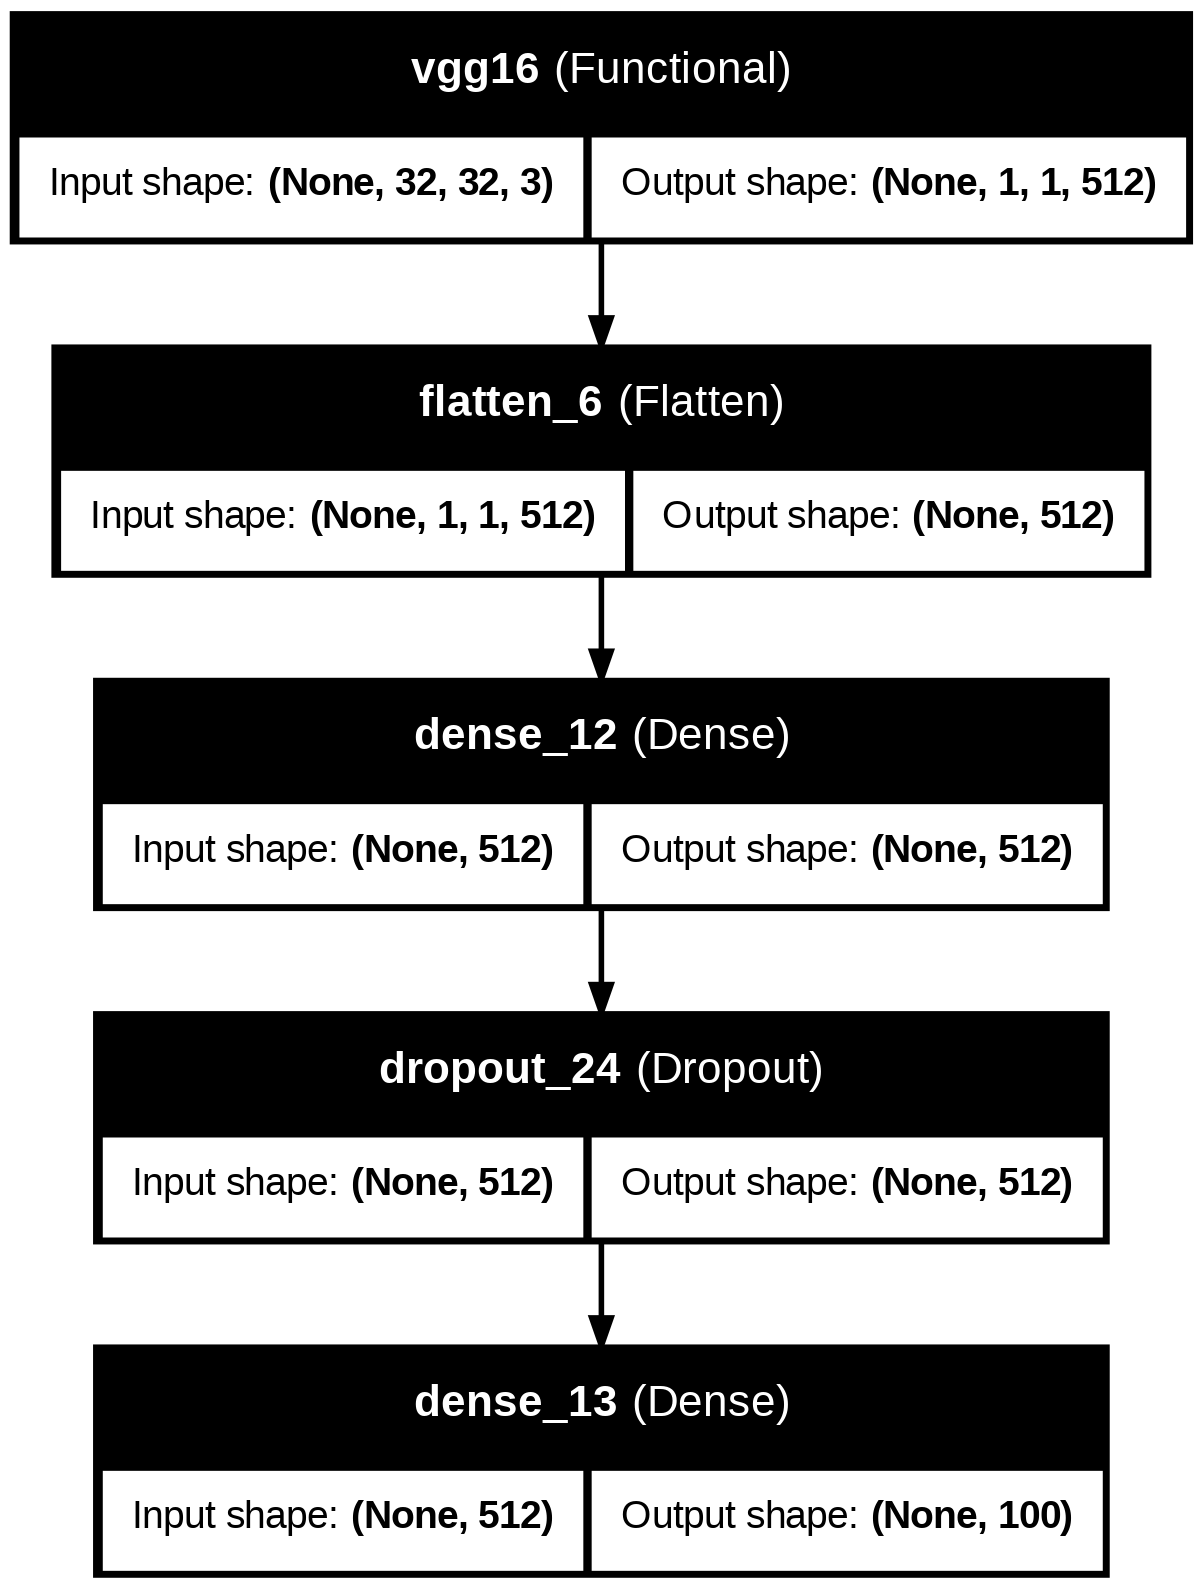

In [13]:
# Plot the VGG-16 architecture
plot_model(vgg16_model, to_file='vgg16_architecture.png', show_shapes=True, show_layer_names=True)
display(Image(filename='vgg16_architecture.png'))


## 8. Callbacks

In [14]:
# Define callbacks
custom_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_custom_cnn.keras', monitor='val_accuracy', save_best_only=True)
]

vgg_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_vgg16.keras', monitor='val_accuracy', save_best_only=True)
]


## 9. Train the Custom CNN


In [15]:
# Train the custom CNN
custom_history = custom_cnn.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=custom_callbacks,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.0913 - loss: 4.2777 - val_accuracy: 0.1689 - val_loss: 3.6336
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1900 - loss: 3.4517 - val_accuracy: 0.2587 - val_loss: 3.1586
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2582 - loss: 3.0752 - val_accuracy: 0.3157 - val_loss: 2.8280
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3125 - loss: 2.8037 - val_accuracy: 0.3757 - val_loss: 2.5246
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3528 - loss: 2.6083 - val_accuracy: 0.3991 - val_loss: 2.4045
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3783 - loss: 2.4809 - val_accuracy: 0.4276 - val_loss: 2.2645
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3998 - loss: 2.3865 - val_accuracy: 0.4440 - val_loss: 2.2061
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4270 - loss: 2.2858 - val_acc

## 10. Train the VGG-16 Model

In [17]:
# Train the VGG-16 model
vgg_history = vgg16_model.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=vgg_callbacks,
    verbose=1
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.0101 - loss: 4.6055 - val_accuracy: 0.0077 - val_loss: 4.6074
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.0102 - loss: 4.6055 - val_accuracy: 0.0077 - val_loss: 4.6077
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.0099 - loss: 4.6055 - val_accuracy: 0.0077 - val_loss: 4.6078
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.0100 - loss: 4.6054 - val_accuracy: 0.0077 - val_loss: 4.6079
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.0102 - loss: 4.6054 - val_accuracy: 0.0077 - val_loss: 4.6079


## 11. Evaluate Both Models on Test Data

In [18]:
# Evaluate both models on the test set
custom_test_loss, custom_test_acc = custom_cnn.evaluate(x_test, y_test_cat, verbose=1)
vgg_test_loss, vgg_test_acc = vgg16_model.evaluate(x_test, y_test_cat, verbose=1)

print(custom_test_loss)
print(custom_test_acc)
print(vgg_test_loss)
print(vgg_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4850 - loss: 2.0703
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.0100 - loss: 4.6054
2.070329189300537
0.48500001430511475
4.605417251586914
0.009999999776482582


## 12. Plot and Compare Training Curves

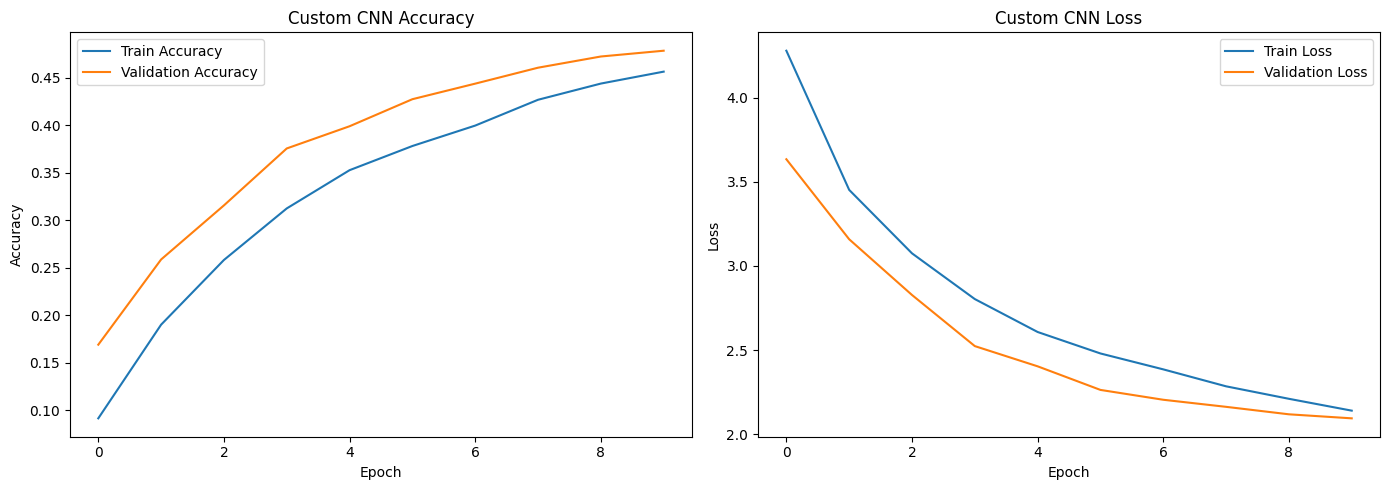

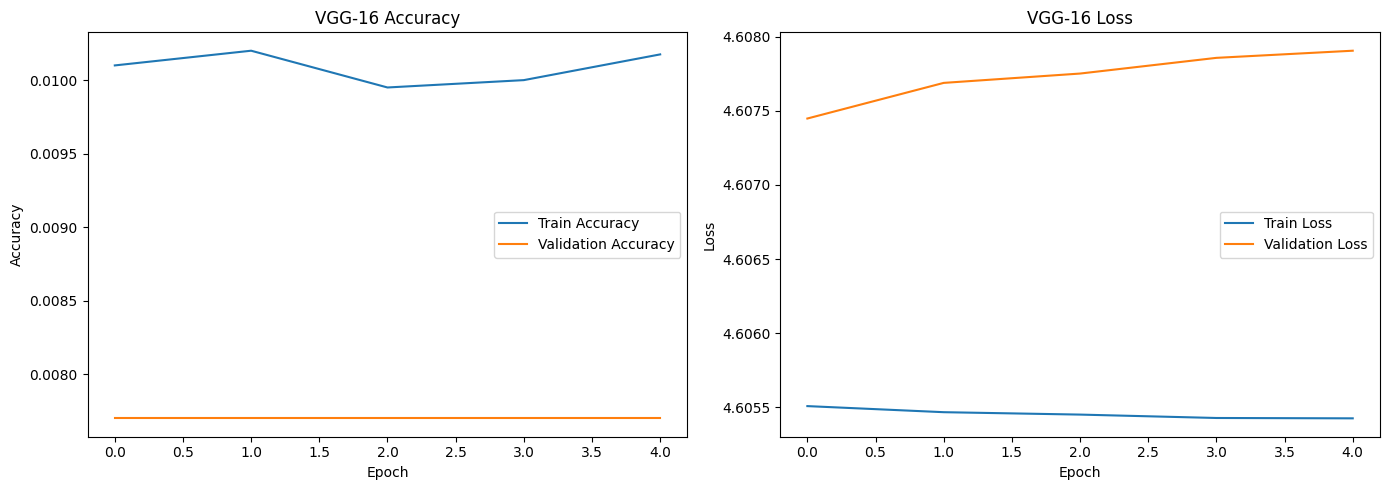

In [19]:
# Plot accuracy and loss curves for both models
def plot_history(history_obj, title_prefix):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_obj.history['accuracy'], label='Train Accuracy')
    plt.plot(history_obj.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title_prefix + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_obj.history['loss'], label='Train Loss')
    plt.plot(history_obj.history['val_loss'], label='Validation Loss')
    plt.title(title_prefix + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(custom_history, 'Custom CNN')
plot_history(vgg_history, 'VGG-16')


## 13. Final Test Accuracy Comparison Table


In [20]:
# Create the final comparison table
results_df = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG-16'],
    'Test Loss': [custom_test_loss, vgg_test_loss],
    'Test Accuracy': [custom_test_acc, vgg_test_acc]
})

results_df


,Model,Test Loss,Test Accuracy
0,Custom CNN,2.070329,0.485
1,VGG-16,4.605417,0.010
